# 5b_GBM_TARGETS — GBM Prediction on Target Grids

Apply trained GBM quantile models (Q05 / Q50 / Q95) to Antarctic and Greenland
target grids, producing a compressed NetCDF per region.

| Variable | Description |
|---|---|
| `gbm_q05/q50/q95_raw` | Raw model predictions (clipped to `[q_clip_min, q_clip_max]`) |
| `gbm_q05/q50/q95_corr` | Spline-corrected: Q50 PCHIP offset propagated identically to Q05/Q95 (interval widths preserved) |
| `gbm_q05/q95_conf` | Conformal bounds: Q05_raw − qhatgbm, Q95_raw + qhatgbm |
| `gbm_iqr90_raw/corr/conf` | Q95 − Q05 for each variant |
| `gbm_std_raw/corr` | Gaussian-equivalent σ = IQR90 / (2 × 1.6449) |

**Bundle read from** `output/models/gbm_artefacts.pkl` (written by 4b_GBM_MODEL).

**Files written**
- `output/targets/Aq15_GBM_v{MODELVERSION}.nc`
- `output/targets/Kq15_GBM_v{MODELVERSION}.nc`


## 1. Imports & constants

In [1]:
import sys, json, pickle, warnings, datetime, time
sys.path.insert(0, ".")
from config import *

import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from scipy.stats import entropy as scipy_entropy
warnings.filterwarnings("ignore")

from lib.utils import grid_from_xr_dataset

targets_dir.mkdir(parents=True, exist_ok=True)

GBM_QUANTILES  = [0.05, 0.50, 0.95]   # the three quantile levels 4b trains
_SIGMA_FACTOR  = 2.0 * 1.6449          # IQR90 → Gaussian σ

print(f"MODEL_VERSION  : {MODEL_VERSION}")
print(f"targets_dir    : {targets_dir}")
print(f"GBM quantiles : {GBM_QUANTILES}")


✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36
MODEL_VERSION  : 0_4
targets_dir    : output/targets
GBM quantiles : [0.05, 0.5, 0.95]


## 2. Helpers

In [2]:
# ── grid loader ────────────────────────────────────────────────────────────────
def load_grid(grid_cfg, obs_sel):
    label = grid_cfg["label"]
    xcol  = grid_cfg["x_col"]
    ycol  = grid_cfg["y_col"]
    df    = pd.read_parquet(grid_cfg["parquet"])
    print(f"  {label.upper():<6s}  {len(df):>10,} rows loaded")

    missing = [f for f in obs_sel if f not in df.columns]
    if missing:
        warnings.warn(f"Missing features in parquet, filling NaN: {missing}")
        for f in missing:
            df[f] = np.nan

    nan_counts = {f: int(df[f].isna().sum()) for f in obs_sel if df[f].isna().any()}
    if nan_counts:
        print(f"  NaN counts per feature: {nan_counts}")
    else:
        print(f"  All {len(obs_sel)} features present, no NaNs in feature columns")

    xvals  = np.sort(df[xcol].unique()).astype(np.float64)
    yvals  = np.sort(df[ycol].unique()).astype(np.float64)
    nx, ny = len(xvals), len(yvals)
    is_reg = (len(df) == nx * ny)
    if is_reg:
        dx = np.diff(xvals)
        dy = np.diff(yvals)
        print(f"  Regular grid {ny}×{nx}  Δx={dx[0]:.0f} m  Δy={dy[0]:.0f} m")
    else:
        print(f"  Irregular: {len(df):,} pts  (regular would be {ny * nx:,})")

    return df, xvals, yvals, ny, nx, is_reg


# ── build scaled feature matrix ────────────────────────────────────────────────
def build_X(df, obs_sel, scaler):
    X_raw  = df[obs_sel].values.astype(np.float32)
    finite = np.isfinite(X_raw).all(axis=1)
    X_sc   = np.full_like(X_raw, np.nan, dtype=np.float32)
    if finite.any():
        X_sc[finite] = scaler.transform(X_raw[finite]).astype(np.float32)
    print(f"  Finite points for prediction: {finite.sum():,} / {len(df):,}")
    return X_sc, finite


# ── reshape 1-D predictions → 2-D (y, x) ─────────────────────────────────────
def to_2d(vals_1d, df, xvals, yvals, xcol, ycol, is_reg):
    ny, nx = len(yvals), len(xvals)
    if is_reg:
        tmp = df[[xcol, ycol]].copy()
        tmp["v"] = vals_1d
        return (tmp.pivot(index=ycol, columns=xcol, values="v")
                   .values.astype(np.float32))
    from scipy.interpolate import griddata
    gx, gy = np.meshgrid(xvals, yvals)
    return griddata(
        df[[xcol, ycol]].values, vals_1d, (gx, gy), method="nearest"
    ).astype(np.float32)


# ── apply PCHIP spline (NaN-safe, clip) ───────────────────────────────────────
def apply_spline(spline, vals):
    out = np.full_like(vals, np.nan, dtype=np.float32)
    ok  = np.isfinite(vals)
    out[ok] = np.clip(
        spline(vals[ok]).astype(np.float32), q_clip_min, q_clip_max
    )
    return out


# ── normalised Shannon entropy ─────────────────────────────────────────────────
def shannon_H_norm(values_2d, binwidth=0.010):
    v = values_2d.ravel()
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return np.nan
    bins      = np.arange(q_clip_min, q_clip_max + binwidth, binwidth)
    counts, _ = np.histogram(v, bins=bins)
    p         = counts / counts.sum()
    p         = p[p > 0]
    H         = float(scipy_entropy(p))
    H_max     = float(np.log(len(bins) - 1))
    return round(H / H_max, 6) if H_max > 0 else 0.0


# ── build xr.Dataset ──────────────────────────────────────────────────────────
def make_ds(arrays, xvals, yvals, grid_cfg, params, obs_sel, model_tag,
            qhatgbm, conformal_alpha, extra=None):
    coords = {"y": yvals, "x": xvals}
    dvars  = {
        name: xr.DataArray(
            arr, dims=["y", "x"], coords=coords,
            attrs={"units": "W m-2", "long_name": name.replace("_", " ")}
        )
        for name, arr in arrays.items()
    }
    attrs = dict(
        title           = f"{model_tag} heat-flow prediction",
        model           = model_tag,
        version         = MODEL_VERSION,
        institution     = NETCDF_AUTHOR,
        Conventions     = NETCDF_CONVENTIONS,
        crs             = grid_cfg["crs"],
        epsg            = str(grid_cfg["epsg"]),
        region          = grid_cfg["label"].upper(),
        created         = datetime.datetime.utcnow().isoformat() + "Z",
        obs_sel         = json.dumps(obs_sel),
        params_json     = json.dumps(params, default=str),
        qhatgbm_wm2     = float(qhatgbm),
        conformal_alpha = float(conformal_alpha),
        spline_note     = ("Q50 PCHIP offset applied to Q50; "
                           "same additive offset propagated to Q05 and Q95 "
                           "(interval widths preserved). "
                           "Raw (uncorrected) variants also saved."),
    )
    if extra:
        attrs.update(extra)
    return xr.Dataset(dvars, coords=coords, attrs=attrs)


# ── save compressed NetCDF ─────────────────────────────────────────────────────
def save_nc(ds, path):
    enc = {
        v: {"zlib": True, "complevel": netcdf_compression_level, "dtype": "float32"}
        for v in ds.data_vars
    }
    ds.to_netcdf(path, encoding=enc)
    print(f"  Saved → {path}  ({path.stat().st_size / 1e6:.1f} MB)")


print("Helpers ready.")


Helpers ready.


## 3. Load GBM artefacts

In [3]:
# 4b writes: modeldir / "gbm_artefacts.pkl"
# Bundle keys (exact, from 4b source):
#   gbmmodels       – dict keyed by float: {0.05: model, 0.50: model, 0.95: model}
#   gbmspline       – PCHIP correction spline
#   obssel          – list of feature names  ← NOTE: NO underscore (obssel, not obs_sel)
#   qhatgbm         – conformal correction scalar (float)
#   quantilelosses  – [0.05, 0.50, 0.95]
#   scaler          – fitted StandardScaler
#   CONFORMALALPHA  – 0.10
#   PARAMS          – sweep parameters dict

artefact_path = model_dir / "gbm_artefacts.pkl"
assert artefact_path.exists(), f"Bundle not found: {artefact_path}"

with open(artefact_path, "rb") as fp:
    art = pickle.load(fp)

print(f"Bundle keys: {list(art.keys())}")

# ── unpack ─────────────────────────────────────────────────────────────────────
gbm_models      = art["models"]           # dict {float → model} (canonical key 'models')
gbm_spline      = art["spline"]           # PCHIP spline (canonical key 'spline')
obs_sel         = art["obs_sel"]          # list[str]
scaler          = art["scaler"]          # StandardScaler
qhat_gbm         = float(art["qhat_gbm"])  # conformal scalar
conformal_alpha = float(art.get("CONFORMAL_ALPHA", 0.10))
quantile_losses = list(art.get("quantile_losses", GBM_QUANTILES))
PARAMS          = art["PARAMS"]

# Verify models are present and keyed correctly (floats)
for q in GBM_QUANTILES:
    assert q in gbm_models, (
        f"Model for q={q} missing from gbm_models. "
        f"Available keys: {list(gbm_models.keys())}"
    )

print(f"obs_sel          : {len(obs_sel)} features")
print(f"quantile_losses  : {quantile_losses}")
print(f"qhatgbm          : {qhat_gbm * 1e3:.3f} mW/m²")
print(f"conformal_alpha  : {conformal_alpha}")
print(f"model type (Q50) : {type(gbm_models[0.50]).__name__}")


Bundle keys: ['models', 'spline', 'obs_sel', 'qhat_gbm', 'quantile_losses', 'scaler', 'CONFORMAL_ALPHA', 'PARAMS']
obs_sel          : 14 features
quantile_losses  : [0.05, 0.5, 0.95]
qhatgbm          : -0.025 mW/m²
conformal_alpha  : 0.1
model type (Q50) : HistGradientBoostingRegressor


## 4. Predict & write NetCDF

For each target grid:
1. Load parquet, verify features  
2. Scale features with train-fold `scaler`  
3. Predict Q05 / Q50 / Q95 with the three GBM models  
4. Spline-correct Q50 → `q50_corr`; propagate **same additive offset** to Q05/Q95  
5. Compute conformal bounds: `Q05_raw − qhatgbm`, `Q95_raw + qhatgbm`  
6. Derive IQR90 and Gaussian-equivalent σ  
7. Reshape 1-D → 2-D (y × x)  
8. Write compressed NetCDF


In [4]:
results_gbm = {}

for grid_cfg in TARGET_GRIDS:
    label    = grid_cfg["label"]
    xcol     = grid_cfg["x_col"]
    ycol     = grid_cfg["y_col"]
    prefix   = "Aq15" if label == "ant" else "Kq15"
    out_path = targets_dir / f"{prefix}_GBM_v{MODEL_VERSION}.nc"

    print(f"\n{'='*60}")
    print(f"REGION: {label.upper()}  →  {out_path.name}")
    print(f"{'='*60}")

    # 1. Load grid
    df, xvals, yvals, ny, nx, is_reg = load_grid(grid_cfg, obs_sel)

    # 2. Scale features
    X_sc, finite = build_X(df, obs_sel, scaler)

    # 3. GBM predictions
    print(f"  Predicting {len(df):,} pts × {len(GBM_QUANTILES)} quantiles …")
    t0 = time.time()

    raw = {}
    for q in GBM_QUANTILES:
        arr = np.full(len(df), np.nan, dtype=np.float32)
        if finite.any():
            arr[finite] = gbm_models[q].predict(X_sc[finite]).astype(np.float32)
        raw[q] = np.clip(arr, q_clip_min, q_clip_max)

    q05_raw = raw[0.05]
    q50_raw = raw[0.50]
    q95_raw = raw[0.95]
    print(f"  Predict wall-time: {(time.time()-t0)/60:.1f} min")

    # 4. Spline correction — Q50 offset propagated to Q05 & Q95
    q50_corr = apply_spline(gbm_spline, q50_raw)
    offset   = q50_corr - q50_raw                              # NaN-safe additive shift

    q05_corr = np.clip(q05_raw + offset, q_clip_min, q_clip_max).astype(np.float32)
    q95_corr = np.clip(q95_raw + offset, q_clip_min, q_clip_max).astype(np.float32)

    # 5. Conformal bounds (applied to raw predictions)
    q05_conf = np.clip(q05_raw - qhat_gbm, q_clip_min, None).astype(np.float32)
    q95_conf = np.clip(q95_raw + qhat_gbm, None, q_clip_max).astype(np.float32)

    # 6. Uncertainty metrics
    iqr90_raw  = np.clip(q95_raw  - q05_raw,  0.0, q_clip_max).astype(np.float32)
    iqr90_corr = np.clip(q95_corr - q05_corr, 0.0, q_clip_max).astype(np.float32)
    iqr90_conf = np.clip(q95_conf - q05_conf, 0.0, q_clip_max).astype(np.float32)

    sigma_raw  = (iqr90_raw  / _SIGMA_FACTOR).astype(np.float32)
    sigma_corr = (iqr90_corr / _SIGMA_FACTOR).astype(np.float32)

    # 7. Reshape 1-D → 2-D
    def r2d(v):
        return to_2d(v, df, xvals, yvals, xcol, ycol, is_reg)

    arrays = {
        "gbm_q05_raw"    : r2d(q05_raw),
        "gbm_q50_raw"    : r2d(q50_raw),
        "gbm_q95_raw"    : r2d(q95_raw),
        "gbm_q05_corr"   : r2d(q05_corr),
        "gbm_q50_corr"   : r2d(q50_corr),
        "gbm_q95_corr"   : r2d(q95_corr),
        "gbm_q05_conf"   : r2d(q05_conf),
        "gbm_q95_conf"   : r2d(q95_conf),
        "gbm_iqr90_raw"  : r2d(iqr90_raw),
        "gbm_iqr90_corr" : r2d(iqr90_corr),
        "gbm_iqr90_conf" : r2d(iqr90_conf),
        "gbm_std_raw"   : r2d(sigma_raw),
        "gbm_std_corr"  : r2d(sigma_corr),
    }

    # Shannon entropy on corrected Q50 field
    H_raw  = shannon_H_norm(arrays["gbm_q50_raw"])
    H_corr = shannon_H_norm(arrays["gbm_q50_corr"])
    print(f"  Shannon H_norm  raw={H_raw:.4f}  corr={H_corr:.4f}")

    # 8. Build and save dataset
    ds = make_ds(
        arrays, xvals, yvals, grid_cfg, PARAMS, obs_sel,
        model_tag       = f"{prefix}_GBM",
        qhatgbm         = qhat_gbm,
        conformal_alpha = conformal_alpha,
        extra={
            "shannon_H_q50_raw"  : H_raw,
            "shannon_H_q50_corr" : H_corr,
        },
    )

    grid_cfg['agrid'] =  grid_from_xr_dataset(ds, name = label)

    save_nc(ds, out_path)
    results_gbm[label] = ds
    print(f"{label.upper()} complete.")

print("\nAll GBM target grids written.")



REGION: ANT  →  Aq15_GBM_v0_4.nc
  ANT      1,779,556 rows loaded
  All 14 features present, no NaNs in feature columns
  Regular grid 1334×1334  Δx=5000 m  Δy=5000 m
  Finite points for prediction: 1,779,556 / 1,779,556
  Predicting 1,779,556 pts × 3 quantiles …
  Predict wall-time: 0.1 min
  Shannon H_norm  raw=0.4769  corr=0.5948
  Saved → output/targets/Aq15_GBM_v0_4.nc  (60.2 MB)
ANT complete.

REGION: GRL  →  Kq15_GBM_v0_4.nc
  GRL        172,360 rows loaded
  All 14 features present, no NaNs in feature columns
  Regular grid 556×310  Δx=4950 m  Δy=4950 m
  Finite points for prediction: 172,360 / 172,360
  Predicting 172,360 pts × 3 quantiles …
  Predict wall-time: 0.0 min
  Shannon H_norm  raw=0.4579  corr=0.5743
  Saved → output/targets/Kq15_GBM_v0_4.nc  (6.3 MB)
GRL complete.

All GBM target grids written.


## 5. Summary statistics

In [5]:
for label, ds in results_gbm.items():
    print(f"\n{label.upper()} variables")
    for var in ds.data_vars:
        v    = ds[var].values
        v_ok = v[np.isfinite(v)] * 1e3   # W/m² → mW/m²
        if len(v_ok) == 0:
            print(f"  {var:<25s}  (all NaN)")
        else:
            print(f"  {var:<25s}  "
                  f"mean={v_ok.mean():6.1f}  "
                  f"std={v_ok.std():5.1f}  "
                  f"[{v_ok.min():.1f}, {v_ok.max():.1f}]  mW/m²")



ANT variables
  gbm_q05_raw                mean=  29.5  std=  6.4  [1.0, 48.1]  mW/m²
  gbm_q50_raw                mean=  64.0  std= 15.7  [12.7, 245.7]  mW/m²
  gbm_q95_raw                mean= 128.5  std= 46.6  [51.8, 350.0]  mW/m²
  gbm_q05_corr               mean=  26.1  std= 10.2  [1.0, 348.4]  mW/m²
  gbm_q50_corr               mean=  60.5  std= 23.0  [1.0, 350.0]  mW/m²
  gbm_q95_corr               mean= 125.0  std= 51.4  [26.4, 350.0]  mW/m²
  gbm_q05_conf               mean=  29.5  std=  6.4  [1.0, 48.1]  mW/m²
  gbm_q95_conf               mean= 128.5  std= 46.6  [51.8, 350.0]  mW/m²
  gbm_iqr90_raw              mean=  99.0  std= 46.4  [13.9, 317.4]  mW/m²
  gbm_iqr90_corr             mean=  99.0  std= 46.4  [1.6, 312.0]  mW/m²
  gbm_iqr90_conf             mean=  99.0  std= 46.4  [13.9, 317.3]  mW/m²
  gbm_std_raw                mean=  30.1  std= 14.1  [4.2, 96.5]  mW/m²
  gbm_std_corr               mean=  30.1  std= 14.1  [0.5, 94.8]  mW/m²

GRL variables
  gbm_q05_raw      

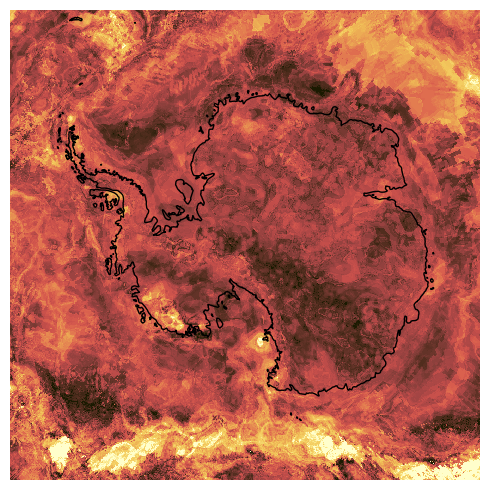

(<Figure size 500x500 with 1 Axes>, <GeoAxes: >)

In [6]:
TARGET_GRIDS[0]['agrid'].map('gbm_q50_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max)